# Contrastive Learning - CCRCC survival

In [1]:
import os
import glob
import json
import random
import pickle
import hashlib
from dataclasses import dataclass, asdict
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, SubsetRandomSampler

from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, balanced_accuracy_score, accuracy_score,
    roc_curve, auc, confusion_matrix, pairwise_distances, silhouette_score,
)

import optuna
from optuna.pruners import MedianPruner


/home/yona/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model contrastive learning

## Shared utilities + hyperparameter search

In [2]:
DATA_ROOT = '/media/Data/Yona/WSI CCRCC'
CSV_PATH  = f'{DATA_ROOT}/tables/clinical+genomic_split.csv'
FEAT_DIR  = f'{DATA_ROOT}/features_MaxPooling'
STEP1_OUT = f'{DATA_ROOT}/runs_supcon_step1_100'
STEP2_OUT = f'{DATA_ROOT}/runs_supcon_step2_final'
STEP3_OUT = f'{DATA_ROOT}/runs_supcon_step3_eval'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def set_seed(seed: int = 42) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ── Supervised contrastive loss (multi-view) ──────────────────────────────────
class SupConLossMV(nn.Module):
    def __init__(self, temperature=0.07, exclude_same_patient=True):
        super().__init__()
        self.temperature = temperature
        self.exclude_same_patient = exclude_same_patient

    def forward(self, features, labels, pids=None):
        device = features.device
        B, V, D = features.shape
        feats = F.normalize(features, dim=2).view(B * V, D)
        labels = labels.view(-1, 1)
        mask_labels = torch.eq(labels, labels.T).float()
        if self.exclude_same_patient and pids is not None:
            pids_np = np.asarray(pids)
            same_pid = torch.tensor(pids_np[:, None] == pids_np[None, :], dtype=torch.float, device=device)
            mask_labels = mask_labels * (1.0 - same_pid)
        mask = mask_labels.repeat_interleave(V, dim=0).repeat_interleave(V, dim=1)
        logits = torch.matmul(feats, feats.T) / self.temperature
        logits_mask = 1.0 - torch.eye(B * V, device=device)
        mask = mask * logits_mask
        logits_max, _ = logits.max(dim=1, keepdim=True)
        logits = logits - logits_max.detach()
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-12)
        pos_count = mask.sum(1)
        return -(mask * log_prob).sum(1).div(pos_count + 1e-12).mean()


def augment_vectors(x, noise_std=0.06, drop_prob=0.25, scale_jitter=0.10):
    x_aug = x + torch.randn_like(x) * noise_std
    x_aug = x_aug * (torch.rand_like(x_aug) > drop_prob).float()
    if scale_jitter > 0:
        scale = 1.0 + (2.0 * torch.rand(x.size(0), 1, device=x.device) - 1.0) * scale_jitter
        x_aug = x_aug * scale
    return x_aug


# ── Contrastive projector + classifier ───────────────────────────────────────
class SupConMLP(nn.Module):
    def __init__(self, input_dim=2048, embed_dim=128, dropout_rate=0.5):
        super().__init__()
        self.projector = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),  nn.BatchNorm1d(512),  nn.ReLU(inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(512, embed_dim)
        )
        self.classifier = nn.Linear(embed_dim, 2)

    def forward(self, x):
        z = self.projector(x)
        return z, self.classifier(z)


# ── Dataset ───────────────────────────────────────────────────────────────────
class WSIEmbeddingDataset(Dataset):
    """Loads .npz embeddings for one or more CSV split names."""
    def __init__(self, csv_path, features_dir, splits=('train',)):
        if isinstance(splits, str):
            splits = (splits,)
        wanted = {s.strip().lower() for s in splits}
        df = pd.read_csv(csv_path)[['case_id', 'vital_status_12', 'Split']]
        data_list = []
        for _, row in df.iterrows():
            if str(row['Split']).strip().lower() not in wanted:
                continue
            cid = str(row['case_id']).strip()
            lbl = int(row['vital_status_12'])
            if cid.startswith('C'):
                pid = cid
            elif cid.startswith('T'):
                parts = cid.split('-')
                if len(parts) < 3:
                    continue
                pid = '-'.join(parts[:3])
            else:
                continue
            for fp in glob.glob(os.path.join(features_dir, f'{pid}-*.npz')):
                data_list.append({'patient_id': pid, 'label': lbl, 'file_path': fp})
        self.data_list = data_list

    def __len__(self): return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        arr = np.load(item['file_path'])
        feat = arr['features'].reshape(-1, arr['features'].shape[-1])[0]  # do not touch
        return torch.tensor(feat, dtype=torch.float), item['label'], item['patient_id']


def make_balanced_loader(ds, batch_size=128, num_workers=4, seed=42):
    labels = [ds[i][1] for i in range(len(ds))]
    cnt = Counter(labels)
    total = len(labels)
    w = {l: total / (len(cnt) * c) for l, c in cnt.items()}
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(ds, batch_size=batch_size, num_workers=num_workers, generator=g,
                      sampler=WeightedRandomSampler([w[l] for l in labels], num_samples=total, replacement=True))


def make_plain_loader(ds, batch_size=256, num_workers=4, shuffle=False):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)


# ── HParams + training helpers ────────────────────────────────────────────────
@dataclass
class HParams:
    epochs: int = 60
    batch_size: int = 128
    lr: float = 5e-4
    temperature: float = 0.07
    noise_std: float = 0.06
    drop_prob: float = 0.25
    scale_jitter: float = 0.10
    lambda_ce: float = 0.1
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    dropout_rate: float = 0.5
    exclude_same_patient: bool = True
    patience: int = 10
    seed: int = 42


def build_ce_loss_from_dataset(ds, device):
    lbls = [ds[i][1] for i in range(len(ds))]
    cnt = Counter(lbls)
    total = len(lbls)
    w = torch.tensor([total / cnt[i] for i in sorted(cnt)], dtype=torch.float, device=device)
    return nn.CrossEntropyLoss(weight=w)


@torch.no_grad()
def validate_epoch(model, loader, supcon, ce, hp: HParams, device):
    model.eval()
    run_s, run_c, run_t, n = 0.0, 0.0, 0.0, 0
    for x_cpu, y_cpu, pid_batch in loader:
        x, y = x_cpu.to(device), y_cpu.to(device)
        x1 = augment_vectors(x, hp.noise_std, hp.drop_prob, hp.scale_jitter)
        x2 = augment_vectors(x, hp.noise_std, hp.drop_prob, hp.scale_jitter)
        z1, _ = model(x1); z2, _ = model(x2)
        feats  = torch.stack([F.normalize(z1, dim=1), F.normalize(z2, dim=1)], dim=1)
        loss_s = supcon(feats, y, pids=pid_batch)
        loss_c = ce(model.classifier((z1 + z2) / 2.0), y)
        loss   = loss_s + hp.lambda_ce * loss_c
        bs = x.size(0)
        run_s += loss_s.item() * bs; run_c += loss_c.item() * bs; run_t += loss.item() * bs; n += bs
    return {'val_supcon': run_s/max(n,1), 'val_ce': run_c/max(n,1), 'val_total': run_t/max(n,1)}


def make_run_id(hp: HParams) -> str:
    return hashlib.md5(json.dumps(asdict(hp), sort_keys=True).encode()).hexdigest()[:10]


def train_one_run(hp: HParams, out_dir: str):
    os.makedirs(out_dir, exist_ok=True)
    torch.manual_seed(hp.seed); np.random.seed(hp.seed)
    train_ds = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=('train',))
    val_ds   = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=('validation',))
    train_loader = make_balanced_loader(train_ds, batch_size=hp.batch_size, seed=hp.seed)
    val_loader   = make_plain_loader(val_ds, batch_size=256, shuffle=False)
    model  = SupConMLP(dropout_rate=hp.dropout_rate).to(device)
    supcon = SupConLossMV(temperature=hp.temperature, exclude_same_patient=hp.exclude_same_patient).to(device)
    ce     = build_ce_loss_from_dataset(train_ds, device)
    opt    = torch.optim.Adam(model.parameters(), lr=hp.lr, weight_decay=hp.weight_decay)
    best_val, best_path, history, bad = float('inf'), os.path.join(out_dir, 'best_model.pth'), [], 0
    for ep in range(1, hp.epochs + 1):
        model.train()
        run_s, run_c, run_t, n = 0.0, 0.0, 0.0, 0
        for x_cpu, y_cpu, pid_batch in train_loader:
            x, y = x_cpu.to(device), y_cpu.to(device)
            x1 = augment_vectors(x, hp.noise_std, hp.drop_prob, hp.scale_jitter)
            x2 = augment_vectors(x, hp.noise_std, hp.drop_prob, hp.scale_jitter)
            z1, _ = model(x1); z2, _ = model(x2)
            feats  = torch.stack([F.normalize(z1,dim=1), F.normalize(z2,dim=1)], dim=1)
            loss_s = supcon(feats, y, pids=pid_batch)
            loss_c = ce(model.classifier((z1+z2)/2.0), y)
            loss   = loss_s + hp.lambda_ce * loss_c
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), hp.grad_clip)
            opt.step()
            bs = x.size(0)
            run_s+=loss_s.item()*bs; run_c+=loss_c.item()*bs; run_t+=loss.item()*bs; n+=bs
        train_m = {'epoch':ep, 'train_supcon':run_s/max(n,1), 'train_ce':run_c/max(n,1), 'train_total':run_t/max(n,1)}
        val_m   = validate_epoch(model, val_loader, supcon, ce, hp, device)
        row     = {**train_m, **val_m}
        history.append(row)
        print(f'[{os.path.basename(out_dir)}|E{ep:02d}] train {row["train_total"]:.4f} val {row["val_total"]:.4f}')
        if row['val_total'] < best_val - 1e-5:
            best_val, bad = row['val_total'], 0
            torch.save({'model_state': model.state_dict(), 'hparams': asdict(hp), 'best_val_total': best_val, 'epoch': ep}, best_path)
        else:
            bad += 1
            if bad >= hp.patience: break
    with open(os.path.join(out_dir, 'history.json'), 'w') as f: json.dump(history, f, indent=2)
    with open(os.path.join(out_dir, 'hparams.json'), 'w') as f: json.dump(asdict(hp), f, indent=2)
    return best_val, best_path


def sample_hparams(rng: np.random.Generator, base: HParams) -> HParams:
    hp = HParams(**asdict(base))
    hp.epochs       = int(rng.integers(30, 81))
    hp.patience     = int(rng.integers(6, 13))
    hp.batch_size   = int(rng.choice([64, 128, 256]))
    hp.lr           = float(10 ** rng.uniform(np.log10(1e-4), np.log10(1e-3)))
    hp.temperature  = float(rng.choice([0.03, 0.05, 0.07, 0.10, 0.15]))
    hp.noise_std    = float(rng.uniform(0.02, 0.10))
    hp.drop_prob    = float(rng.uniform(0.05, 0.40))
    hp.scale_jitter = float(rng.uniform(0.00, 0.20))
    hp.lambda_ce    = float(rng.choice([0.0, 0.05, 0.1, 0.2, 0.3]))
    hp.dropout_rate = float(rng.choice([0.1, 0.3, 0.5]))
    hp.weight_decay = float(10 ** rng.uniform(np.log10(1e-6), np.log10(5e-4)))
    hp.grad_clip    = float(rng.choice([0.5, 1.0, 2.0, 5.0]))
    hp.exclude_same_patient = True
    hp.seed = 42
    return hp


def run_100_trials(n_trials=100, master_seed=123):
    os.makedirs(STEP1_OUT, exist_ok=True)
    base_hp = HParams()
    rng     = np.random.default_rng(master_seed)
    best    = {'val': float('inf'), 'path': None, 'hparams': None, 'trial': None}
    results = []
    seen    = set()
    for t in range(1, n_trials + 1):
        hp = sample_hparams(rng, base_hp)
        run_id = make_run_id(hp)
        tries = 0
        while run_id in seen and tries < 50:
            hp = sample_hparams(rng, base_hp); run_id = make_run_id(hp); tries += 1
        seen.add(run_id)
        run_dir = os.path.join(STEP1_OUT, f'trial_{t:03d}_{run_id}')
        print(f'\n=== Trial {t}/{n_trials} ({run_id}) ===')
        val, ckpt = train_one_run(hp, run_dir)
        res = {'trial': t, 'run_id': run_id, 'val_total': val, 'ckpt': ckpt, 'hparams': asdict(hp)}
        results.append(res)
        if val < best['val']:
            best = {'val': val, 'path': ckpt, 'hparams': asdict(hp), 'trial': t, 'run_id': run_id}
        with open(os.path.join(STEP1_OUT, 'all_results.json'), 'w') as f: json.dump(results, f, indent=2)
        with open(os.path.join(STEP1_OUT, 'best_hparams.json'), 'w') as f: json.dump(best, f, indent=2)
    print('\n=== BEST ==='); print(json.dumps(best, indent=2))
    return best


Using device: cuda


## Step 1 - run 100 hyperparameter trials

In [3]:
best = run_100_trials(n_trials=100, master_seed=123)



=== Trial 1/100 (276a002915) ===
[trial_001_276a002915|E01] train 8.4107 val 5.6247
[trial_001_276a002915|E02] train 6.5795 val 4.8724
[trial_001_276a002915|E03] train 5.9268 val 4.7924
[trial_001_276a002915|E04] train 5.7611 val 4.7734
[trial_001_276a002915|E05] train 5.7009 val 4.7680
[trial_001_276a002915|E06] train 5.6717 val 4.7698
[trial_001_276a002915|E07] train 5.6545 val 4.7710
[trial_001_276a002915|E08] train 5.6447 val 4.7672
[trial_001_276a002915|E09] train 5.6358 val 4.7638
[trial_001_276a002915|E10] train 5.6209 val 4.7664
[trial_001_276a002915|E11] train 5.6146 val 4.7767
[trial_001_276a002915|E12] train 5.6085 val 4.7632
[trial_001_276a002915|E13] train 5.6007 val 4.7785
[trial_001_276a002915|E14] train 5.5841 val 4.7944
[trial_001_276a002915|E15] train 5.5775 val 4.8141
[trial_001_276a002915|E16] train 5.5714 val 4.8131
[trial_001_276a002915|E17] train 5.5463 val 4.9154
[trial_001_276a002915|E18] train 5.5186 val 4.8962
[trial_001_276a002915|E19] train 5.4751 val 4.96

## Step 2 - Train final contrastive model (train + val)

In [3]:
@torch.no_grad()
def extract_projected_embeddings(model, ds, batch_size=256, num_workers=4):
    model.eval().to(device)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    E_list, y_list, pid_list = [], [], []
    for x_cpu, y_cpu, pid_batch in loader:
        z, _ = model(x_cpu.to(device))
        E_list.append(F.normalize(z, dim=1).cpu().numpy())
        y_list.append(y_cpu.numpy())
        pid_list.extend(list(pid_batch))
    return np.vstack(E_list), np.concatenate(y_list), np.array(pid_list)


def save_split_embeddings(out_dir, split_name, E_proj, y, pid):
    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, f'{split_name}_projected.npy'), E_proj)
    np.save(os.path.join(out_dir, f'{split_name}_labels.npy'),    y)
    np.save(os.path.join(out_dir, f'{split_name}_patient_ids.npy'), pid)


def _mean_upper_triangle(mat):
    n = mat.shape[0]
    if n < 2: return float('nan'), 0
    vals = mat[np.triu_indices(n, k=1)]
    return (float(np.mean(vals)) if vals.size > 0 else float('nan')), int(vals.size)


def _mean_between_blocks(mat, ia, ib):
    if len(ia) == 0 or len(ib) == 0: return float('nan'), 0
    block = mat[np.ix_(ia, ib)]
    return float(np.mean(block)), int(block.size)


def tsne_and_metrics(embeddings, labels, title='', do_plot=True, seed=42):
    E = np.asarray(embeddings, dtype=np.float32)
    y = np.asarray(labels, dtype=int)
    N = E.shape[0]
    print(f'\n=== {title} === N={N}')
    if do_plot:
        E2 = TSNE(n_components=2, perplexity=30, random_state=seed).fit_transform(E)
        plt.figure(figsize=(8, 6))
        plt.scatter(E2[:, 0], E2[:, 1], c=y, cmap='coolwarm', alpha=0.7)
        plt.title(title); plt.show()
    cos_d = pairwise_distances(E, metric='cosine')
    euc_d = pairwise_distances(E, metric='euclidean')
    same  = y[:, None] == y[None, :]
    diag  = np.eye(N, dtype=bool)
    cos_intra = float(cos_d[same & ~diag].mean()) if (same & ~diag).sum() > 0 else float('nan')
    cos_inter = float(cos_d[~same].mean())         if (~same).sum() > 0 else float('nan')
    euc_intra = float(euc_d[same & ~diag].mean()) if (same & ~diag).sum() > 0 else float('nan')
    euc_inter = float(euc_d[~same].mean())         if (~same).sum() > 0 else float('nan')
    sil_cos = float(silhouette_score(E, y, metric='cosine'))    if len(np.unique(y)) > 1 else float('nan')
    sil_euc = float(silhouette_score(E, y, metric='euclidean')) if len(np.unique(y)) > 1 else float('nan')
    print(f'Cosine   intra={cos_intra:.4f} inter={cos_inter:.4f} delta={cos_inter-cos_intra:.4f}')
    print(f'Euclid   intra={euc_intra:.4f} inter={euc_inter:.4f} delta={euc_inter-euc_intra:.4f}')
    print(f'Silhouette cosine={sil_cos:.4f} euclidean={sil_euc:.4f}')
    for c in np.unique(y):
        ic, nc = np.where(y==c)[0], np.where(y!=c)[0]
        ci, _ = _mean_upper_triangle(cos_d[np.ix_(ic,ic)])
        cx, _ = _mean_between_blocks(cos_d, ic, nc)
        print(f'  Class {c}: n={len(ic)} cos_intra={ci:.4f} cos_inter={cx:.4f} delta={cx-ci:.4f}')


def train_final_trainval(best_hparams: dict):
    os.makedirs(STEP2_OUT, exist_ok=True)
    trainval_ds = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=('train', 'validation'))
    loader      = make_balanced_loader(trainval_ds, batch_size=int(best_hparams['batch_size']),
                                       seed=int(best_hparams.get('seed', 42)))
    model  = SupConMLP(dropout_rate=float(best_hparams['dropout_rate'])).to(device)
    supcon = SupConLossMV(temperature=float(best_hparams['temperature']),
                          exclude_same_patient=bool(best_hparams['exclude_same_patient'])).to(device)
    ce     = build_ce_loss_from_dataset(trainval_ds, device)
    opt    = torch.optim.Adam(model.parameters(), lr=float(best_hparams['lr']),
                              weight_decay=float(best_hparams['weight_decay']))
    epochs     = int(best_hparams['epochs'])
    grad_clip  = float(best_hparams['grad_clip'])
    lambda_ce  = float(best_hparams['lambda_ce'])
    aug_kw = {'noise_std': float(best_hparams['noise_std']),
              'drop_prob': float(best_hparams['drop_prob']),
              'scale_jitter': float(best_hparams['scale_jitter'])}
    for ep in range(1, epochs + 1):
        model.train()
        run_s, run_c, run_t, n = 0.0, 0.0, 0.0, 0
        for x_cpu, y_cpu, pid_batch in loader:
            x, y = x_cpu.to(device), y_cpu.to(device)
            x1 = augment_vectors(x, **aug_kw); x2 = augment_vectors(x, **aug_kw)
            z1, _ = model(x1); z2, _ = model(x2)
            feats  = torch.stack([F.normalize(z1,dim=1), F.normalize(z2,dim=1)], dim=1)
            loss_s = supcon(feats, y, pids=pid_batch)
            loss_c = ce(model.classifier((z1+z2)/2.0), y)
            loss   = loss_s + lambda_ce * loss_c
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip); opt.step()
            bs = x.size(0)
            run_s+=loss_s.item()*bs; run_c+=loss_c.item()*bs; run_t+=loss.item()*bs; n+=bs
        print(f'[FINAL|E{ep:02d}] SupCon {run_s/max(n,1):.4f} CE {run_c/max(n,1):.4f} total {run_t/max(n,1):.4f}')
    final_path = os.path.join(STEP2_OUT, 'final_model.pth')
    torch.save({'model_state': model.state_dict(), 'hparams': best_hparams}, final_path)
    print('\nSaved final model to:', final_path)
    return model, trainval_ds, final_path


def evaluate_final(final_ckpt_path: str):
    os.makedirs(STEP3_OUT, exist_ok=True)
    ckpt   = torch.load(final_ckpt_path, map_location=device)
    model  = SupConMLP(dropout_rate=float(ckpt['hparams']['dropout_rate'])).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    train_ds = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=('train',))
    val_ds   = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=('validation',))
    test_ds  = WSIEmbeddingDataset(CSV_PATH, FEAT_DIR, splits=('test',))
    E_tr, y_tr, pid_tr = extract_projected_embeddings(model, train_ds)
    E_va, y_va, pid_va = extract_projected_embeddings(model, val_ds)
    E_te, y_te, pid_te = extract_projected_embeddings(model, test_ds)
    save_split_embeddings(STEP3_OUT, 'train', E_tr, y_tr, pid_tr)
    save_split_embeddings(STEP3_OUT, 'val',   E_va, y_va, pid_va)
    save_split_embeddings(STEP3_OUT, 'test',  E_te, y_te, pid_te)
    tsne_and_metrics(E_tr, y_tr, title='Projected Embeddings (TRAIN)')
    tsne_and_metrics(E_va, y_va, title='Projected Embeddings (VAL)')
    tsne_and_metrics(E_te, y_te, title='Projected Embeddings (TEST)')
    print('\nSaved projected embeddings to:', STEP3_OUT)
    return {'train':{'E':E_tr,'y':y_tr,'pid':pid_tr}, 'val':{'E':E_va,'y':y_va,'pid':pid_va}, 'test':{'E':E_te,'y':y_te,'pid':pid_te}}


### Execution - Step 2 + 3

[FINAL|E01] SupCon 5.7081 CE 0.6658 total 5.7081
[FINAL|E02] SupCon 5.5204 CE 0.6623 total 5.5204
[FINAL|E03] SupCon 5.5107 CE 0.6697 total 5.5107
[FINAL|E04] SupCon 5.4973 CE 0.6865 total 5.4973
[FINAL|E05] SupCon 5.4792 CE 0.6989 total 5.4792
[FINAL|E06] SupCon 5.4323 CE 0.7334 total 5.4323
[FINAL|E07] SupCon 5.4310 CE 0.7253 total 5.4310
[FINAL|E08] SupCon 5.3966 CE 0.7243 total 5.3966
[FINAL|E09] SupCon 5.3675 CE 0.7271 total 5.3675
[FINAL|E10] SupCon 5.3563 CE 0.7222 total 5.3563
[FINAL|E11] SupCon 5.3339 CE 0.7226 total 5.3339
[FINAL|E12] SupCon 5.3113 CE 0.7134 total 5.3113
[FINAL|E13] SupCon 5.2854 CE 0.7152 total 5.2854
[FINAL|E14] SupCon 5.2730 CE 0.7086 total 5.2730
[FINAL|E15] SupCon 5.2620 CE 0.7021 total 5.2620
[FINAL|E16] SupCon 5.2437 CE 0.7017 total 5.2437
[FINAL|E17] SupCon 5.2377 CE 0.6982 total 5.2377
[FINAL|E18] SupCon 5.2232 CE 0.6957 total 5.2232
[FINAL|E19] SupCon 5.1940 CE 0.6951 total 5.1940
[FINAL|E20] SupCon 5.1808 CE 0.6961 total 5.1808
[FINAL|E21] SupCon 5

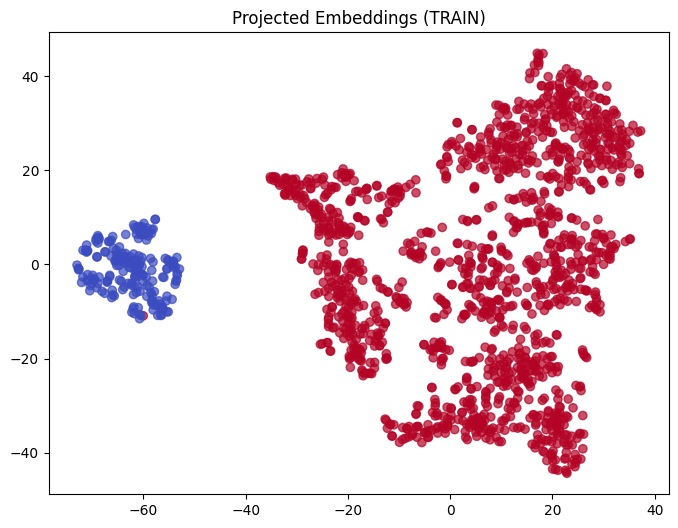

Cosine   intra=0.0098 inter=0.2970 delta=0.2872
Euclid   intra=0.1173 inter=0.7663 delta=0.6491
Silhouette cosine=0.9564 euclidean=0.8425
  Class 0: n=195 cos_intra=0.0035 cos_inter=0.2970 delta=0.2935
  Class 1: n=1467 cos_intra=0.0099 cos_inter=0.2970 delta=0.2871

=== Projected Embeddings (VAL) === N=57


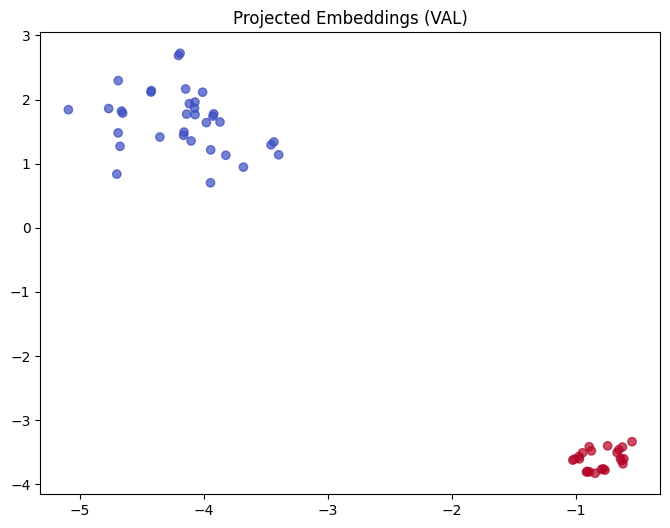

Cosine   intra=0.0035 inter=0.2963 delta=0.2928
Euclid   intra=0.0759 inter=0.7679 delta=0.6920
Silhouette cosine=0.9863 euclidean=0.8945
  Class 0: n=34 cos_intra=0.0020 cos_inter=0.2963 delta=0.2942
  Class 1: n=23 cos_intra=0.0066 cos_inter=0.2963 delta=0.2896

=== Projected Embeddings (TEST) === N=415


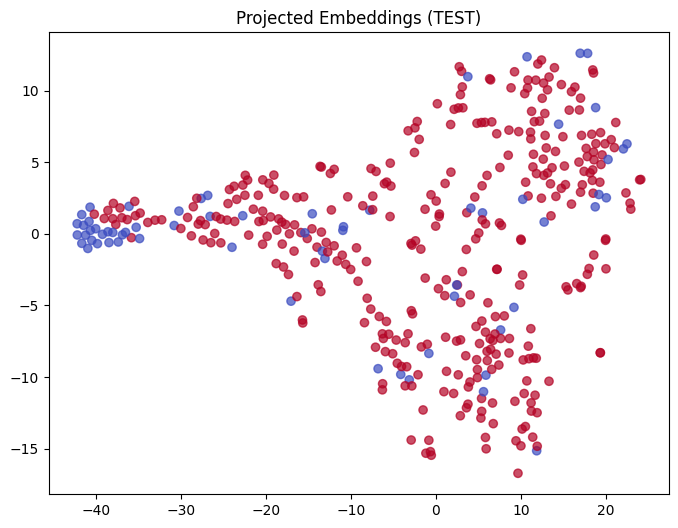

Cosine   intra=0.0286 inter=0.0902 delta=0.0616
Euclid   intra=0.1838 inter=0.3379 delta=0.1541
Silhouette cosine=0.5442 euclidean=0.3751
  Class 0: n=65 cos_intra=0.1062 cos_inter=0.0902 delta=-0.0160
  Class 1: n=350 cos_intra=0.0260 cos_inter=0.0902 delta=0.0642

Saved projected embeddings to: /media/Data/Yona/WSI CCRCC/runs_supcon_step3_eval


In [5]:
BEST_HPARAMS = {
    'epochs': 51, 'batch_size': 128,
    'lr': 0.0005131184270422824, 'temperature': 0.07,
    'noise_std': 0.03065273868172472, 'drop_prob': 0.303790416647357,
    'scale_jitter': 0.1814350939430519, 'lambda_ce': 0.0,
    'weight_decay': 8.104365296022333e-05, 'grad_clip': 5.0,
    'dropout_rate': 0.3, 'exclude_same_patient': True, 'patience': 6, 'seed': 42
}

model, trainval_ds, final_path = train_final_trainval(BEST_HPARAMS)
splits_dict = evaluate_final(final_path)


# Predictive model

## Hyperparameter tuning with Optuna

In [4]:
set_seed(42)


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.1, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = float(alpha); self.gamma = float(gamma); self.reduction = reduction

    def forward(self, logits, targets):
        targets  = targets.float()
        bce      = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs    = torch.sigmoid(logits)
        p_t      = probs * targets + (1.0 - probs) * (1.0 - targets)
        alpha_t  = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        loss     = alpha_t * (1.0 - p_t).pow(self.gamma) * bce
        return loss.mean() if self.reduction == 'mean' else (loss.sum() if self.reduction == 'sum' else loss)


class PatientLevelDataset(Dataset):
    def __init__(self, emb_path, label_path, pid_path):
        self.embeddings = np.load(emb_path).astype(np.float32)
        self.labels     = np.load(label_path).astype(np.int64)
        self.pids       = np.load(pid_path)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.embeddings[idx]), torch.tensor(self.labels[idx])


def make_patient_loader(ds, batch_size=32, balance=False, seed=42, drop_last=True):
    g = torch.Generator(); g.manual_seed(seed)
    if not balance:
        return DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0, generator=g, drop_last=drop_last)
    rng   = np.random.default_rng(seed)
    idx0  = np.where(ds.labels == 0)[0]
    idx1  = np.where(ds.labels == 1)[0]
    n     = min(len(idx0), len(idx1))
    idx   = np.hstack([rng.choice(idx0,n,replace=True), rng.choice(idx1,n,replace=True)])
    rng.shuffle(idx)
    return DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(idx.tolist()),
                      num_workers=0, generator=g, drop_last=drop_last)


class DeepMLPClassifier(nn.Module):
    def __init__(self, input_dim, dropout=0.5, hidden_mult=1.0):
        super().__init__()
        def h(base): return max(8, int(base * hidden_mult))
        self.net = nn.Sequential(
            nn.Linear(input_dim, h(512)), nn.BatchNorm1d(h(512)), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(h(512), h(256)),   nn.BatchNorm1d(h(256)), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(h(256), h(128)),   nn.BatchNorm1d(h(128)), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(h(128), h(64)),    nn.BatchNorm1d(h(64)),  nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(h(64), 1),
        )

    def forward(self, x): return self.net(x).squeeze(1)


@torch.no_grad()
def eval_bacc(model, loader, threshold, device):
    model.eval()
    all_preds, all_labels = [], []
    for xb, yb in loader:
        probs = torch.sigmoid(model(xb.to(device))).cpu().numpy()
        all_preds.extend((probs > threshold).astype(int).tolist())
        all_labels.extend(yb.numpy().astype(int).tolist())
    return balanced_accuracy_score(all_labels, all_preds)


@torch.no_grad()
def find_best_threshold_on_val(model, loader, device, grid=None):
    model.eval()
    probs_all, labels_all = [], []
    for xb, yb in loader:
        probs_all.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
        labels_all.append(yb.numpy().astype(int))
    probs_all  = np.concatenate(probs_all)
    labels_all = np.concatenate(labels_all)
    best_t, best_b = 0.5, -1.0
    for t in (grid if grid is not None else np.linspace(0.05, 0.95, 19)):
        b = balanced_accuracy_score(labels_all, (probs_all > t).astype(int))
        if b > best_b: best_b, best_t = b, float(t)
    return best_t, float(best_b)


def train_patient_model_one_run_optuna(train_loader, valid_loader, input_dim,
                                        lr, wd, n_epochs, noise_std, dropout,
                                        focal_alpha, focal_gamma,
                                        threshold_mode, threshold_value,
                                        hidden_mult, seed, trial=None):
    set_seed(seed)
    model     = DeepMLPClassifier(input_dim=input_dim, dropout=dropout, hidden_mult=hidden_mult).to(device)
    criterion = FocalLoss(alpha=focal_alpha, gamma=focal_gamma)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    g_noise   = torch.Generator(device=device); g_noise.manual_seed(seed)
    best_bacc, best_thr, best_state = -1.0, 0.5, None
    for ep in range(1, n_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            if xb.size(0) < 2: continue
            xb, yb = xb.to(device), yb.to(device)
            if noise_std and (yb == 0).any():
                mask = (yb == 0)
                xb = xb.clone()
                xb[mask] = xb[mask] + torch.randn(xb[mask].shape, device=device, generator=g_noise) * noise_std
            loss = criterion(model(xb), yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        thr, bacc = (find_best_threshold_on_val(model, valid_loader, device=device)
                     if threshold_mode == 'auto'
                     else (float(threshold_value), eval_bacc(model, valid_loader, float(threshold_value), device)))
        if trial is not None:
            trial.report(bacc, step=ep)
            if trial.should_prune(): raise optuna.TrialPruned()
        if bacc > best_bacc:
            best_bacc, best_thr = float(bacc), float(thr)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if best_state is not None: model.load_state_dict(best_state)
    return best_bacc, best_thr


In [7]:
train_ds  = PatientLevelDataset(f'{STEP3_OUT}/train_projected.npy', f'{STEP3_OUT}/train_labels.npy', f'{STEP3_OUT}/train_patient_ids.npy')
val_ds    = PatientLevelDataset(f'{STEP3_OUT}/val_projected.npy',   f'{STEP3_OUT}/val_labels.npy',   f'{STEP3_OUT}/val_patient_ids.npy')
test_ds   = PatientLevelDataset(f'{STEP3_OUT}/test_projected.npy',  f'{STEP3_OUT}/test_labels.npy',  f'{STEP3_OUT}/test_patient_ids.npy')
input_dim = train_ds.embeddings.shape[1]
print(f'Input dim={input_dim} | Train={len(train_ds)} | Val={len(val_ds)} | Test={len(test_ds)}')


def objective(trial):
    seed           = 42
    lr             = trial.suggest_float('lr', 1e-5, 5e-2, log=True)
    wd             = trial.suggest_float('wd', 1e-7, 1e-3, log=True)
    dropout        = trial.suggest_float('dropout', 0.0, 0.7)
    n_epochs       = trial.suggest_int('epochs', 20, 80)
    batch_size     = trial.suggest_categorical('batch_size', [8, 16, 32, 64, 128])
    noise_std      = trial.suggest_float('noise_std', 0.0, 0.05)
    focal_alpha    = trial.suggest_float('focal_alpha', 0.01, 0.5)
    focal_gamma    = trial.suggest_float('focal_gamma', 0.5, 5.0)
    hidden_mult    = trial.suggest_float('hidden_mult', 0.5, 1.5)
    threshold_mode = trial.suggest_categorical('threshold_mode', ['auto', 'fixed'])
    threshold_val  = 0.5 if threshold_mode == 'auto' else trial.suggest_float('threshold', 0.05, 0.95)
    balance_train  = trial.suggest_categorical('balance_train', [True, False])
    tr_ld = make_patient_loader(train_ds, batch_size=batch_size, balance=balance_train, seed=seed, drop_last=True)
    va_ld = make_patient_loader(val_ds,   batch_size=batch_size, balance=False,         seed=seed, drop_last=False)
    best_bacc, best_thr = train_patient_model_one_run_optuna(
        tr_ld, va_ld, input_dim, lr=lr, wd=wd, n_epochs=n_epochs, noise_std=noise_std,
        dropout=dropout, focal_alpha=focal_alpha, focal_gamma=focal_gamma,
        threshold_mode=threshold_mode, threshold_value=threshold_val,
        hidden_mult=hidden_mult, seed=seed, trial=trial,
    )
    trial.set_user_attr('best_threshold', best_thr)
    return best_bacc


study = optuna.create_study(
    direction='maximize',
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=10, interval_steps=1)
)
study.optimize(objective, n_trials=80, show_progress_bar=True)
print('Best Val BACC:', study.best_value)
print('Best Params:  ', study.best_params)
print('Best Threshold:', study.best_trial.user_attrs.get('best_threshold'))


[I 2026-06-08 18:39:17,098] A new study created in memory with name: no-name-5a89ed7d-54f1-4b9e-a4da-818535bdf3ba


Input dim=128 | Train=1662 | Val=57 | Test=415


  0%|          | 0/80 [00:00<?, ?it/s]

Best trial: 0. Best value: 1:   1%|▏         | 1/80 [01:00<1:19:16, 60.21s/it]

[I 2026-06-08 18:40:17,311] Trial 0 finished with value: 1.0 and parameters: {'lr': 0.00887927430065775, 'wd': 0.0005858884859257643, 'dropout': 0.049803763791685614, 'epochs': 67, 'batch_size': 16, 'noise_std': 0.03706313429959126, 'focal_alpha': 0.4467795408270178, 'focal_gamma': 3.7388879428826254, 'hidden_mult': 1.1291842670528092, 'threshold_mode': 'auto', 'balance_train': False}. Best is trial 0 with value: 1.0.


...

[I 2026-06-08 19:07:06,260] Trial 77 finished with value: 1.0 and parameters: {'lr': 0.0003123607576233085, 'wd': 5.747833581663131e-06, 'dropout': 0.10602888881758266, 'epochs': 67, 'batch_size': 128, 'noise_std': 0.01880070333454711, 'focal_alpha': 0.1845954661889837, 'focal_gamma': 2.4892306849663264, 'hidden_mult': 1.490036421507725, 'threshold_mode': 'auto', 'balance_train': False}. Best is trial 0 with value: 1.0.


Best trial: 0. Best value: 1:  99%|█████████▉| 79/80 [28:11<00:12, 12.19s/it]

[I 2026-06-08 19:07:28,886] Trial 78 finished with value: 1.0 and parameters: {'lr': 1.8813301607395666e-05, 'wd': 3.352330579641113e-05, 'dropout': 0.38481454805265575, 'epochs': 24, 'batch_size': 16, 'noise_std': 0.044218731172798335, 'focal_alpha': 0.2067973638851888, 'focal_gamma': 4.47054745860771, 'hidden_mult': 1.402821961199313, 'threshold_mode': 'fixed', 'threshold': 0.4492526043740453, 'balance_train': False}. Best is trial 0 with value: 1.0.


Best trial: 0. Best value: 1: 100%|██████████| 80/80 [28:23<00:00, 21.30s/it]

[I 2026-06-08 19:07:40,728] Trial 79 finished with value: 1.0 and parameters: {'lr': 8.149211834260027e-05, 'wd': 1.8457526261689625e-05, 'dropout': 0.07341499364238119, 'epochs': 28, 'batch_size': 8, 'noise_std': 0.021325589076548364, 'focal_alpha': 0.285080291934162, 'focal_gamma': 4.9940141050553875, 'hidden_mult': 0.6593487816183962, 'threshold_mode': 'auto', 'balance_train': True}. Best is trial 0 with value: 1.0.
Best Val BACC: 1.0
Best Params:   {'lr': 0.00887927430065775, 'wd': 0.0005858884859257643, 'dropout': 0.049803763791685614, 'epochs': 67, 'batch_size': 16, 'noise_std': 0.03706313429959126, 'focal_alpha': 0.4467795408270178, 'focal_gamma': 3.7388879428826254, 'hidden_mult': 1.1291842670528092, 'threshold_mode': 'auto', 'balance_train': False}
Best Threshold: 0.75


## Final model

Epoch 01 | TrainLoss 0.0070 ValLoss 0.0382 | TrainBAcc 0.8755 ValBAcc 1.0000
Epoch 02 | TrainLoss 0.0010 ValLoss 0.0590 | TrainBAcc 0.9792 ValBAcc 1.0000
Epoch 03 | TrainLoss 0.0007 ValLoss 0.0006 | TrainBAcc 0.9948 ValBAcc 1.0000
Epoch 04 | TrainLoss 0.0007 ValLoss 0.0001 | TrainBAcc 0.9869 ValBAcc 1.0000
Epoch 05 | TrainLoss 0.0003 ValLoss 0.0001 | TrainBAcc 0.9974 ValBAcc 1.0000
Epoch 06 | TrainLoss 0.0001 ValLoss 0.0001 | TrainBAcc 1.0000 ValBAcc 1.0000
Epoch 07 | TrainLoss 0.0004 ValLoss 0.0005 | TrainBAcc 0.9974 ValBAcc 1.0000
Epoch 08 | TrainLoss 0.0001 ValLoss 0.0008 | TrainBAcc 1.0000 ValBAcc 1.0000
Epoch 09 | TrainLoss 0.0001 ValLoss 0.0001 | TrainBAcc 1.0000 ValBAcc 1.0000
Epoch 10 | TrainLoss 0.0001 ValLoss 0.0000 | TrainBAcc 0.9974 ValBAcc 1.0000
Epoch 11 | TrainLoss 0.0000 ValLoss 0.0000 | TrainBAcc 1.0000 ValBAcc 1.0000
Epoch 12 | TrainLoss 0.0000 ValLoss 0.0000 | TrainBAcc 1.0000 ValBAcc 1.0000
Epoch 13 | TrainLoss 0.0001 ValLoss 0.0000 | TrainBAcc 0.9974 ValBAcc 1.0000

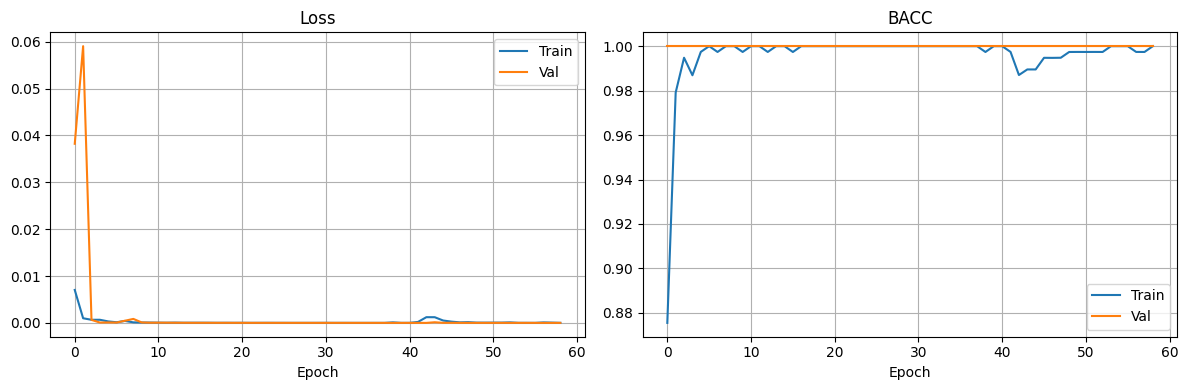

=== TEST Results ===
              precision    recall  f1-score   support

Non-Survival     0.6053    0.3538    0.4466        65
    Survival     0.8886    0.9571    0.9216       350

    accuracy                         0.8627       415
   macro avg     0.7469    0.6555    0.6841       415
weighted avg     0.8442    0.8627    0.8472       415

ACC:  0.8627
BACC: 0.6555
Sensitivity=0.9571  Specificity=0.3538

Confusion matrix:
[[ 23  42]
 [ 15 335]]


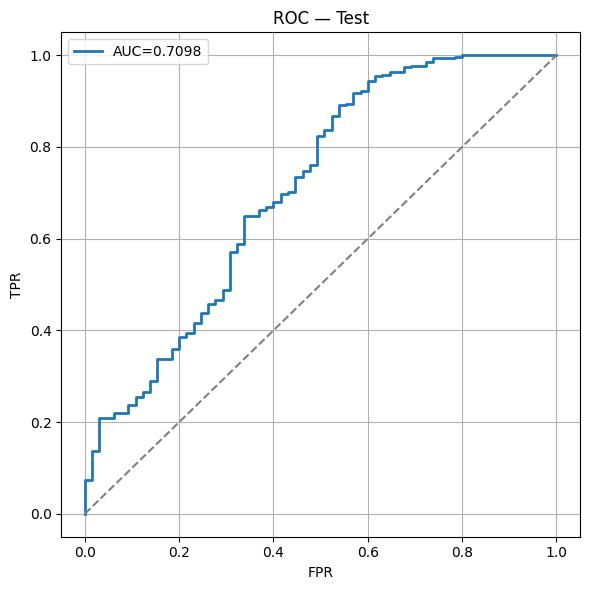

In [5]:
best_params = {
    'lr': 0.0077541624211588745,
    'wd': 9.398208248245877e-07,
    'dropout': 0.02593253032092366,
    'epochs': 59,
    'batch_size': 32,
    'noise_std': 0.04107613097479171,
    'focal_alpha': 0.039381542501504795,
    'focal_gamma': 2.728245294228253,
    'hidden_mult': 0.9819061069663042,
    'threshold_mode': 'auto',
    'balance_train': True,
    'threshold': 0.55,
}

# data (reload in case cells 10-11 not run)
train_ds = PatientLevelDataset(f'{STEP3_OUT}/train_projected.npy', f'{STEP3_OUT}/train_labels.npy', f'{STEP3_OUT}/train_patient_ids.npy')
val_ds   = PatientLevelDataset(f'{STEP3_OUT}/val_projected.npy',   f'{STEP3_OUT}/val_labels.npy',   f'{STEP3_OUT}/val_patient_ids.npy')
test_ds  = PatientLevelDataset(f'{STEP3_OUT}/test_projected.npy',  f'{STEP3_OUT}/test_labels.npy',  f'{STEP3_OUT}/test_patient_ids.npy')
input_dim = train_ds.embeddings.shape[1]

tr_ld  = make_patient_loader(train_ds, batch_size=best_params['batch_size'], balance=best_params['balance_train'], seed=42)
va_ld  = make_patient_loader(val_ds,   batch_size=best_params['batch_size'], balance=False, seed=42)
te_ld  = make_patient_loader(test_ds,  batch_size=best_params['batch_size'], balance=False, seed=42, drop_last=False)


def eval_loader_metrics(model, loader, criterion, threshold):
    model.eval()
    run_loss, n = 0.0, 0
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            run_loss += criterion(logits, yb).item() * xb.size(0); n += xb.size(0)
            probs = torch.sigmoid(logits).cpu().numpy()
            y_prob.extend(probs.tolist())
            y_pred.extend((probs > threshold).astype(int).tolist())
            y_true.extend(yb.cpu().numpy().astype(int).tolist())
    return run_loss/max(1,n), accuracy_score(y_true,y_pred), balanced_accuracy_score(y_true,y_pred)


def train_final_model(train_loader, val_loader, input_dim, params, seed=42):
    set_seed(seed)
    model     = DeepMLPClassifier(input_dim=input_dim, dropout=params['dropout'], hidden_mult=params.get('hidden_mult',1.0)).to(device)
    criterion = FocalLoss(alpha=params['focal_alpha'], gamma=params['focal_gamma'])
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['wd'])
    g_noise   = torch.Generator(device=device); g_noise.manual_seed(seed)
    history   = {'train_loss':[],'val_loss':[],'train_bacc':[],'val_bacc':[]}
    for ep in range(1, params['epochs'] + 1):
        model.train()
        run_loss, n = 0.0, 0
        y_true_ep, y_pred_ep, y_prob_ep = [], [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            if params['noise_std'] and (yb == 0).any():
                mask = (yb == 0); xb = xb.clone()
                xb[mask] = xb[mask] + torch.randn(xb[mask].shape, device=device, generator=g_noise) * params['noise_std']
            logits = model(xb); loss = criterion(logits, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            run_loss += loss.item() * xb.size(0); n += xb.size(0)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            y_prob_ep.extend(probs.tolist())
            y_pred_ep.extend((probs > params['threshold']).astype(int).tolist())
            y_true_ep.extend(yb.cpu().numpy().astype(int).tolist())
        tr_loss = run_loss/max(1,n)
        tr_bacc = balanced_accuracy_score(y_true_ep, y_pred_ep)
        va_loss, _, va_bacc = eval_loader_metrics(model, val_loader, criterion, params['threshold'])
        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['train_bacc'].append(tr_bacc); history['val_bacc'].append(va_bacc)
        print(f'Epoch {ep:02d} | TrainLoss {tr_loss:.4f} ValLoss {va_loss:.4f} | TrainBAcc {tr_bacc:.4f} ValBAcc {va_bacc:.4f}')
    return model, history


final_model, history = train_final_model(tr_ld, va_ld, input_dim, best_params, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True); axes[0].legend()
axes[1].plot(history['train_bacc'], label='Train'); axes[1].plot(history['val_bacc'], label='Val')
axes[1].set_title('BACC'); axes[1].set_xlabel('Epoch'); axes[1].grid(True); axes[1].legend()
plt.tight_layout(); plt.show()

# ── Test evaluation ───────────────────────────────────────────────────────────
final_model.eval()
y_true, y_pred, y_prob = [], [], []
with torch.no_grad():
    for xb, yb in te_ld:
        probs = torch.sigmoid(final_model(xb.to(device))).cpu().numpy()
        y_prob.extend(probs.tolist())
        y_pred.extend((probs > best_params['threshold']).astype(int).tolist())
        y_true.extend(yb.numpy().astype(int).tolist())

print('=== TEST Results ===')
print(classification_report(y_true, y_pred, digits=4, target_names=['Non-Survival','Survival']))
print(f'ACC:  {accuracy_score(y_true,y_pred):.4f}')
print(f'BACC: {balanced_accuracy_score(y_true,y_pred):.4f}')
tn,fp,fn,tp = confusion_matrix(y_true,y_pred).ravel()
print(f'Sensitivity={tp/(tp+fn+1e-12):.4f}  Specificity={tn/(tn+fp+1e-12):.4f}')
print('\nConfusion matrix:'); print(confusion_matrix(y_true,y_pred))

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, lw=2, label=f'AUC={roc_auc:.4f}')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — Test'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()
